# Стройконтроль СМР — аналитический проект к РК-1

Автор: Медиханов Тимур. Самостоятельный курсовой проект, без заявленной связи с дипломом.

Notebook покрывает все шесть пунктов задания. Исходные расчёты выполнены на полном архиве Chicago Building Violations; здесь используются компактные **зафиксированные таблицы**, включённые в Git. Полный аудит исходного CSV: `python -m src.pipeline`.

Перед запуском установите `requirements.txt` в выбранное Python-окружение. Запускайте ячейки сверху вниз. Установка пакетов не выполняется скрыто внутри анализа.

In [1]:
from pathlib import Path
import sys, json
root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/pipeline.py").exists()), None)
assert root is not None, "Откройте notebook из папки репозитория"
sys.path.insert(0, str(root))
import pandas as pd
from IPython.display import display, Image, Markdown
from src import pipeline
from src.pipeline import REP, FIG, OUT, RAW


## 1. Постановка задачи

Пользователь — координатор инспекций. Решение — приоритет внимания к уже запланированной проверке. Выход — вероятность FAILED среди зарегистрированных в журнале инспекций с FAILED/PASSED. Одна строка = одна инспекция.

Критерий успеха на будущих наблюдениях: AP ≥ Dummy AP + 0.05, recall ≥ 0.80, precision ≥ доли FAILED. Цена FN=5 и FP=1 условная, подлежит согласованию. Предполагается, что служба, категория, дата и координаты известны до осмотра.

Архив нарушений не охватывает все проверки. Результат не переносится автоматически на локальные СМР.

## 2. Источник и фиксированный снимок

[Chicago Building Violations](https://data.cityofchicago.org/Buildings/Building-Violations/22u3-xenr). Открытый CSV экспорт без токена; живой источник может измениться. В manifest сохранены время, URL, размер и SHA-256.

In [2]:
manifest = json.loads((RAW / 'manifest.json').read_text())
quality = json.loads((REP / 'quality.json').read_text())
display(pd.Series(manifest))
display(pd.Series({k: quality[k] for k in ['rows','columns','date_min','date_max','objects','inspection_ids','labeled_inspections']}))

url                     https://data.cityofchicago.org/api/views/22u3-...
dataset_id                                                      22u3-xenr
retrieved_at                             2026-10-09T16:48:53.994542+05:00
rows_updated_at_unix                                           1791528815
sha256                  fd1c8de7cc2638a0464a190b65eb0461a829094f13742b...
csv_bytes                                                       931341834
analysis_cutoff                                                2026-10-09
note                    Live archive; local checksum identifies the an...
dtype: object

rows                               2032070
columns                                 26
date_min               2006-01-01 00:00:00
date_max               2026-10-08 00:00:00
objects                             155788
inspection_ids                      470576
labeled_inspections                 357763
dtype: object

## 3. Качество данных — восемь пунктов

Конкретный чек-лист преподавателя не предоставлен; применён стандартный перечень:
1. Структура и типы — явное приведение и проверка ошибок разбора дат.
2. Полнота — NULL и пустые строки по каждому полю, отсутствие ключей.
3. Уникальность — повтор ID и полная копия строки; гранулярность инспекции отдельно.
4. Допустимые значения — даты и грубая координатная рамка Чикаго.
5. Согласованность — единый статус, объект, дата, служба, категория внутри инспекции.
6. Метка — только FAILED=1/PASSED=0; прочие статусы исключаются.
7. Репрезентативность — один город, журнал нарушений, изменения объёма, неполный 2026.
8. Утечка и время — исключение постфактум полей, календарное разделение, отсутствие версий на момент осмотра.

Разные violation_date внутри inspection_number считаются неоднозначностью даты и консервативно исключаются из модели. Это не доказанная ошибка источника. Подробные решения описаны в отчёте.

In [3]:
display(pd.Series(quality))
missing = pd.read_csv(REP / 'missingness.csv')
display(missing)
inspections = pd.read_parquet(OUT / 'inspections.parquet')
model_data = pd.read_parquet(OUT / 'model_data.parquet')
assert inspections.inspection_number.is_unique
assert model_data.inspection_status.isin(['FAILED','PASSED']).all()
assert not model_data.ambiguous.any()

rows                                                                    2032070
columns                                                                      26
duplicate_ids                                                                 0
duplicate_rows                                                                0
bad_dates                                                                     0
reversed_status_dates                                                         0
missing_coordinates                                                        2020
outside_coordinates                                                           0
missing_keys                                                                  0
date_min                                                    2006-01-01 00:00:00
date_max                                                    2026-10-08 00:00:00
objects                                                                  155788
inspection_ids                          

,column,missing_n,missing_pct
0,ssa,1637485,80.582116
1,violation_status_date,1167715,57.464310
2,violation_location,1031042,50.738508
3,violation_inspector_comments,190886,9.393672
4,violation_ordinance,59203,2.913433
5,street_type,16006,0.787670
6,violation_description,14767,0.726697
7,location,2020,0.099406
8,longitude,2020,0.099406
9,latitude,2020,0.099406


## 4. Разведочный анализ — семь графиков

Графики строятся заново по компактным таблицам. Пропуски raw-полей берутся из полного сохранённого аудита. Эти описательные графики не доказывают причинность.

In [4]:
insights = pipeline.explore(inspections, model_data, missing)

### График 1

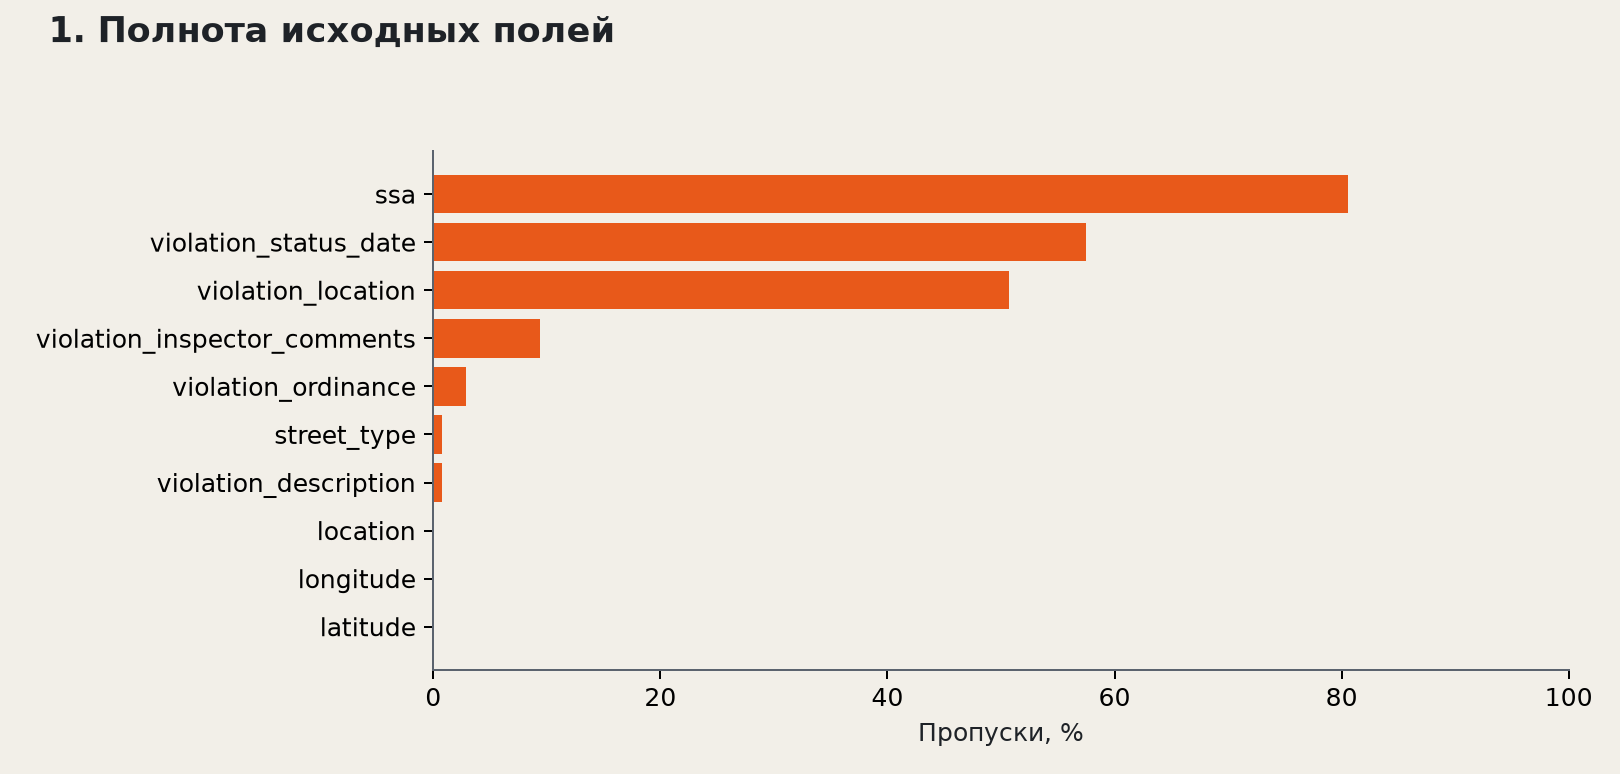

**Вывод.** Максимальная доля пропусков — 80.6% в ssa. Даты статуса, комментарии и SSA не включены в модель; координаты заполняются медианой только по train с индикатором пропуска.

In [5]:
display(Image(filename=str(FIG / (insights[0]['id'] + '.png'))))
display(Markdown('**Вывод.** ' + insights[0]['conclusion']))

### График 2

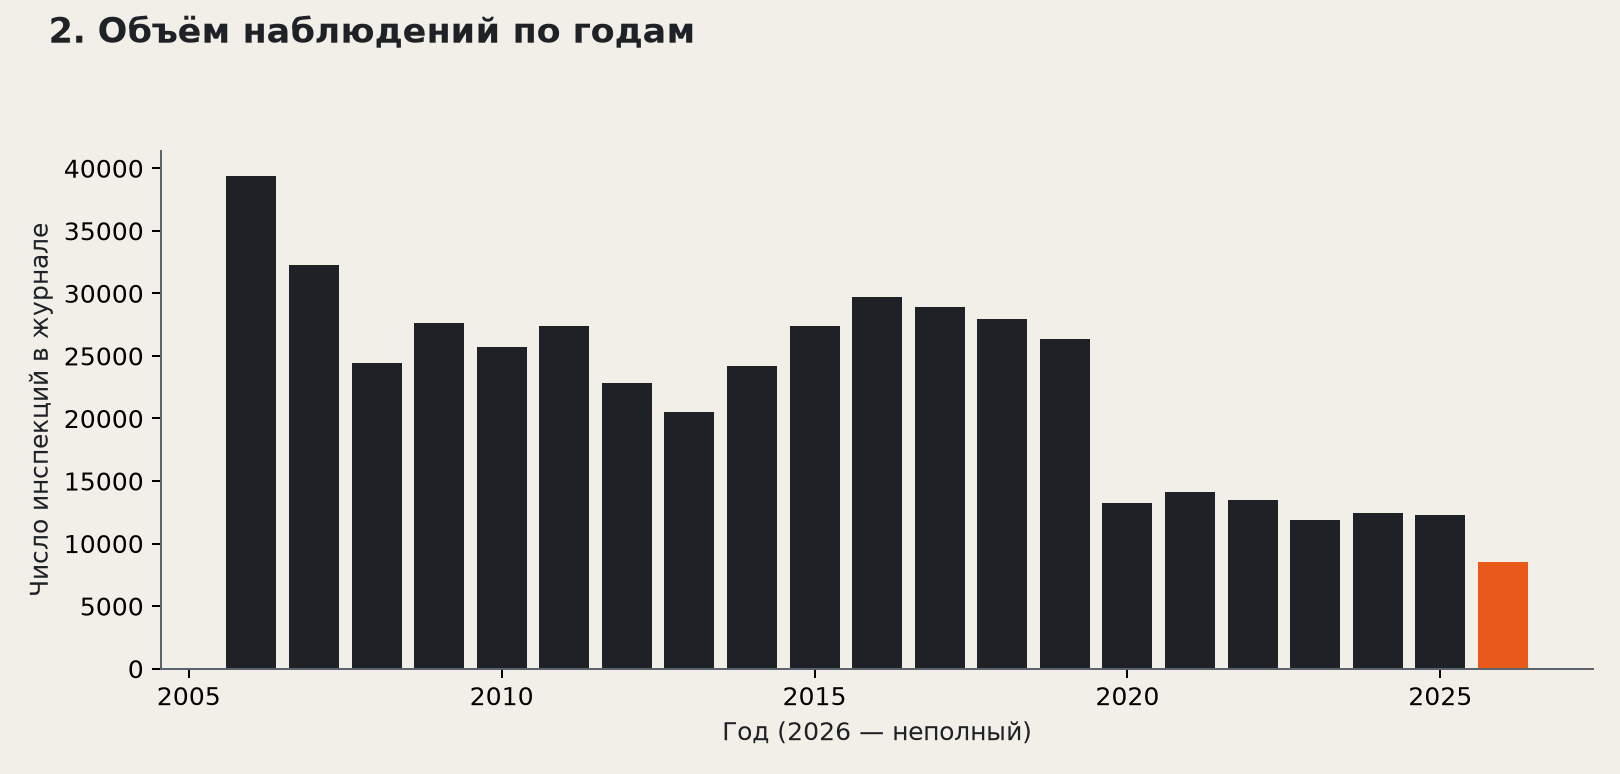

**Вывод.** Максимум в архиве — 2006 год: 39,385 инспекций. 2026 год неполный и не используется как тест. Изменение объёма отражает и практику регистрации, поэтому не доказывает изменение качества зданий.

In [6]:
display(Image(filename=str(FIG / (insights[1]['id'] + '.png'))))
display(Markdown('**Вывод.** ' + insights[1]['conclusion']))

### График 3

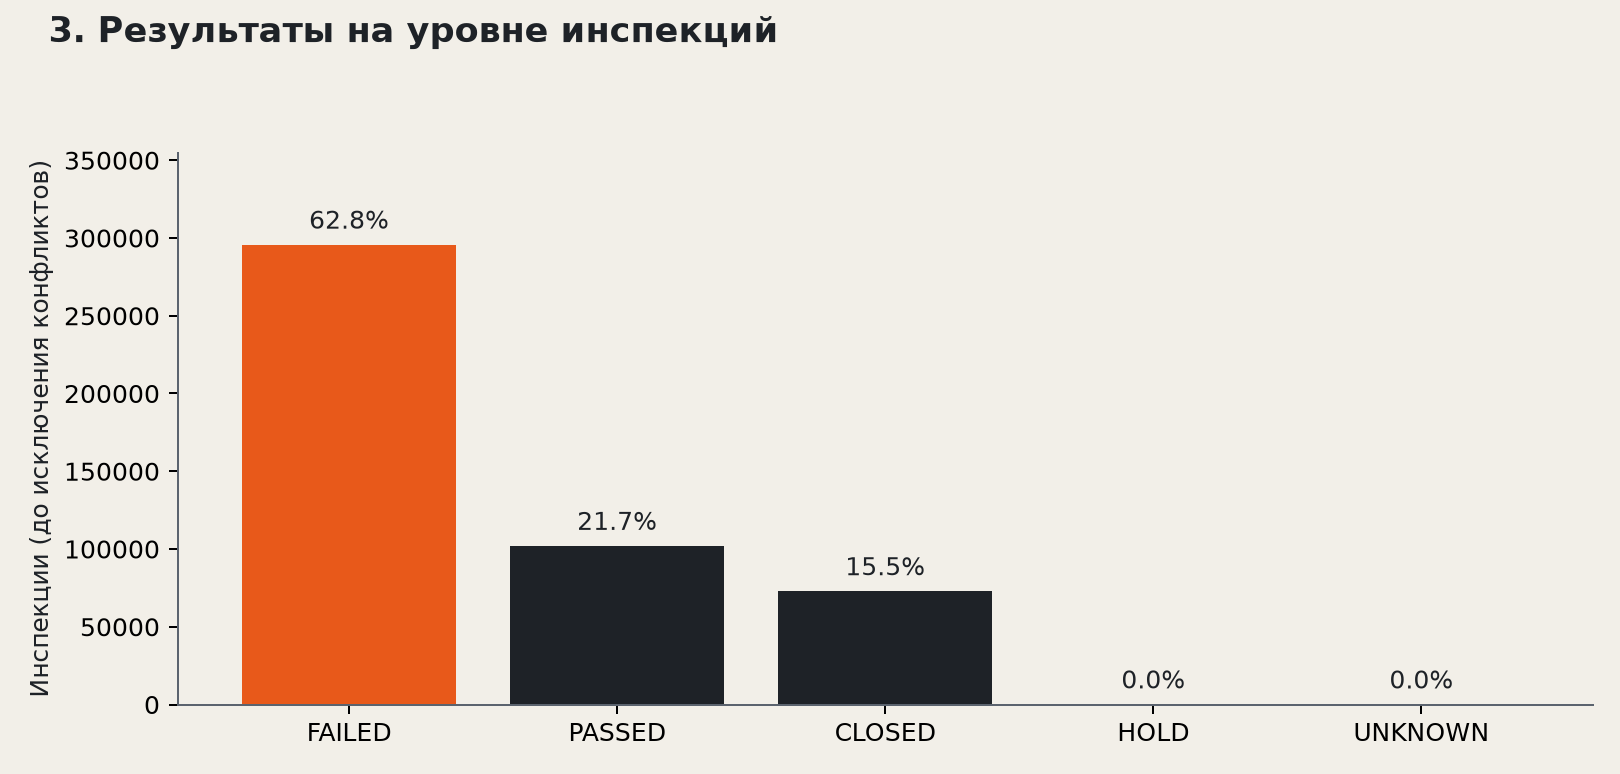

**Вывод.** В бинарной выборке FAILED составляет 73.7%. CLOSED, HOLD и UNKNOWN исключены: отсутствие FAILED не означает PASSED. Accuracy без метрик классов может скрывать пропуски проблемных проверок.

In [7]:
display(Image(filename=str(FIG / (insights[2]['id'] + '.png'))))
display(Markdown('**Вывод.** ' + insights[2]['conclusion']))

### График 4

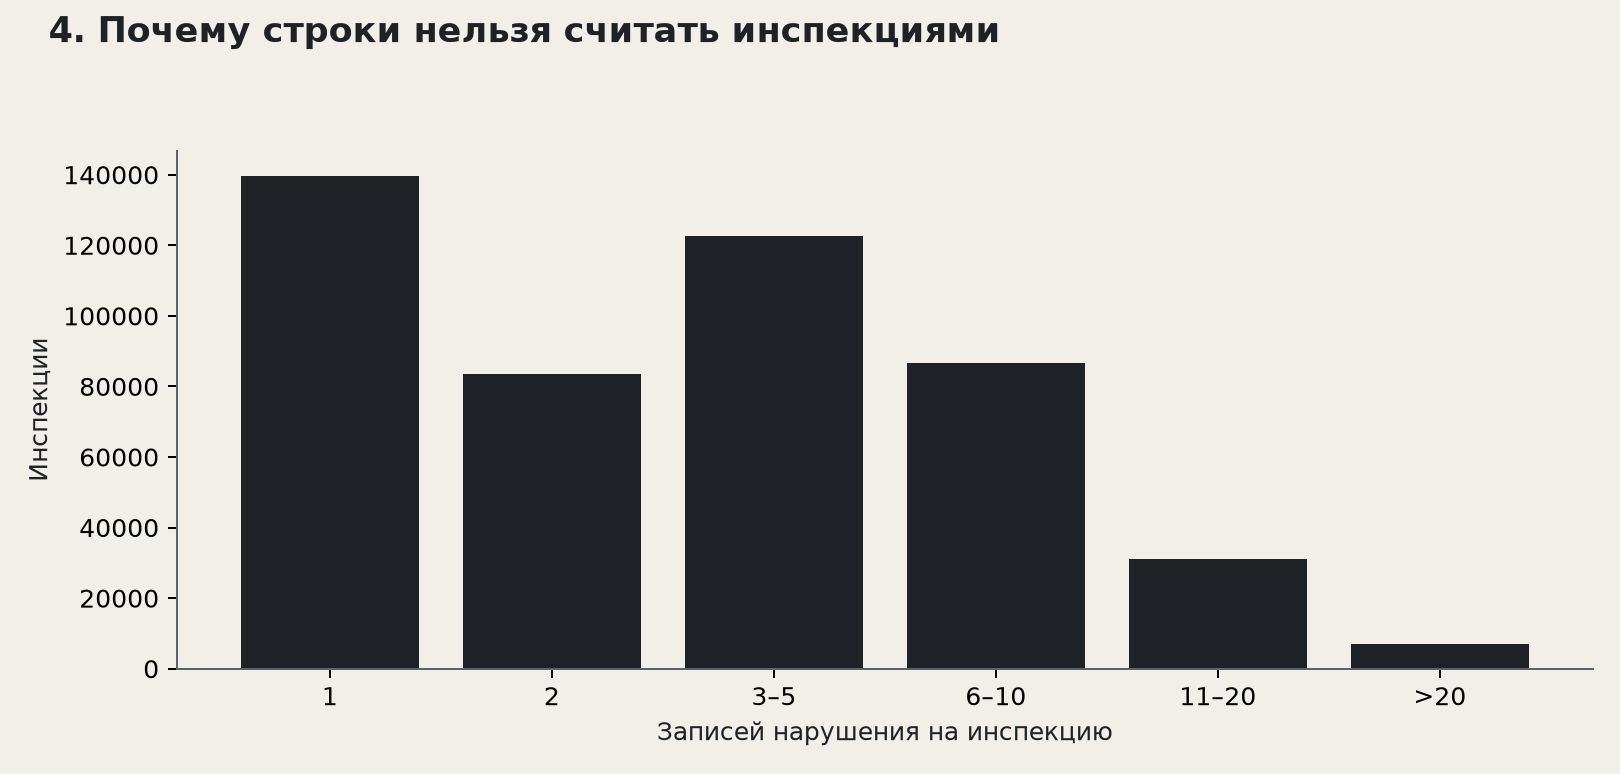

**Вывод.** Медиана — 3 записи, 95-й перцентиль — 13, максимум — 538. Доля FAILED по строкам перевзвешивает инспекции с большим числом нарушений. Число нарушений текущей проверки используется только в EDA.

In [8]:
display(Image(filename=str(FIG / (insights[3]['id'] + '.png'))))
display(Markdown('**Вывод.** ' + insights[3]['conclusion']))

### График 5

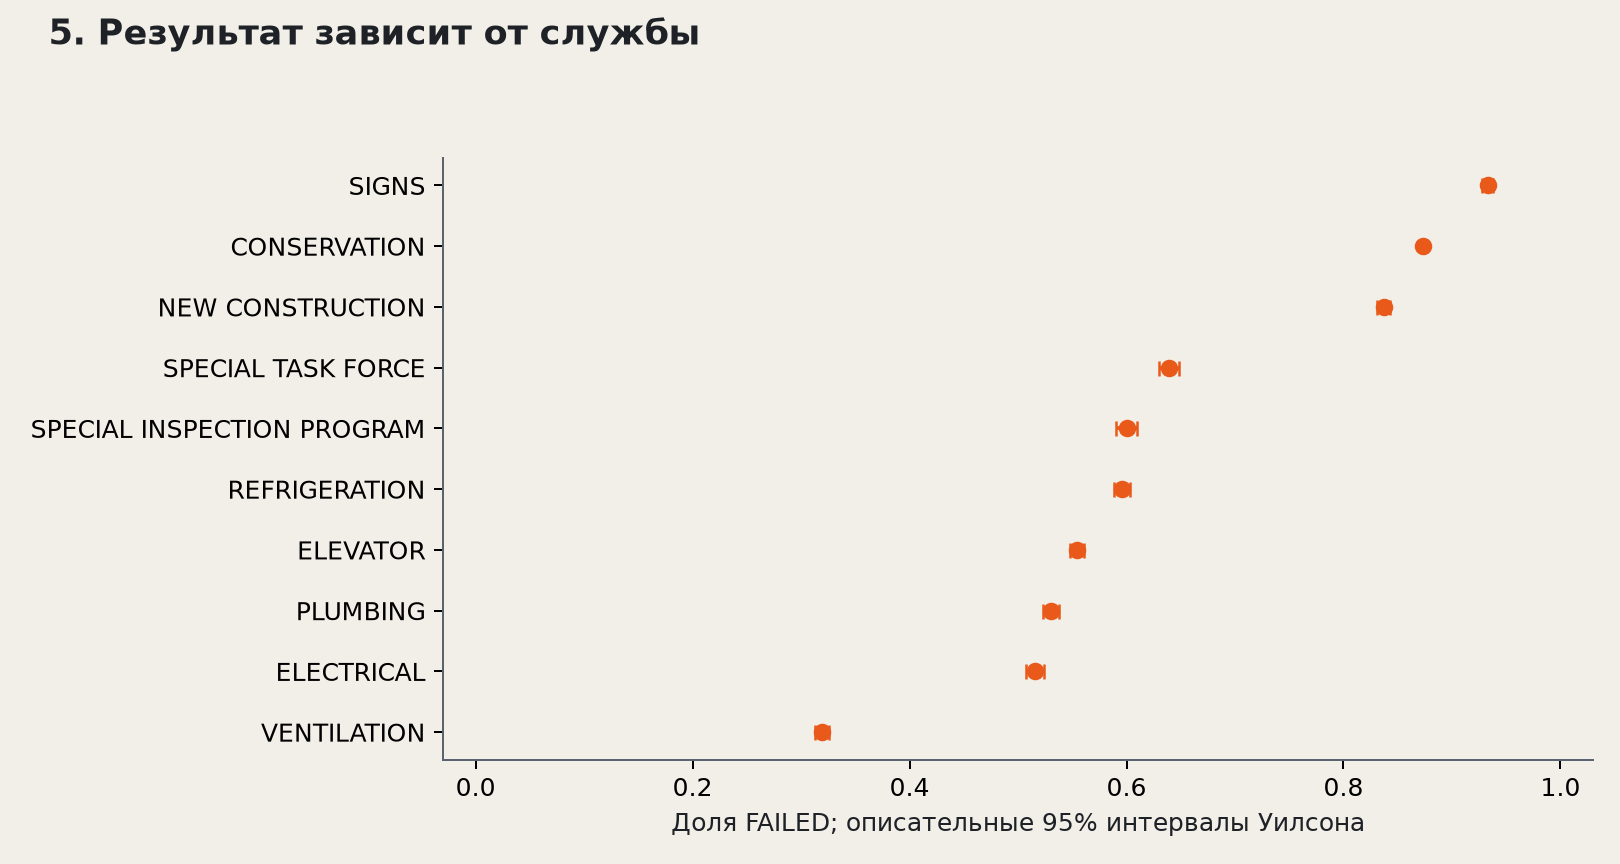

**Вывод.** Среди 10 крупнейших служб доля FAILED меняется от 31.9% до 93.3%. Служба — кандидат в признаки, но различие может отражать процедуры учёта. Интервалы описательные и не учитывают зависимость повторных инспекций одного объекта.

In [9]:
display(Image(filename=str(FIG / (insights[4]['id'] + '.png'))))
display(Markdown('**Вывод.** ' + insights[4]['conclusion']))

### График 6

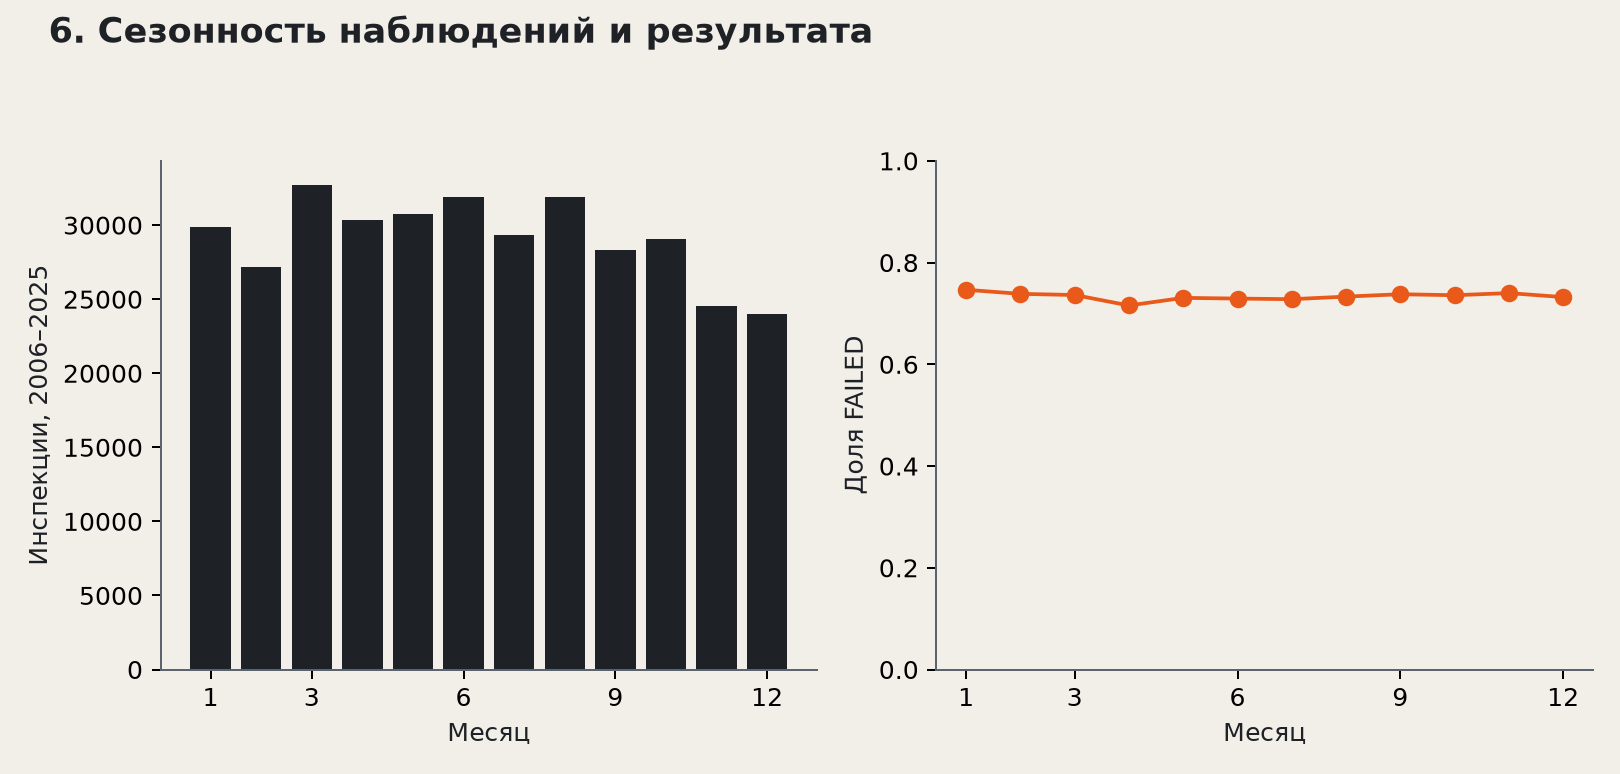

**Вывод.** В полных годах месячная доля FAILED составляет 71.6%–74.7%. Месяц кодируется циклически; это ассоциация, смешанная с составом служб и лет, а не причинный эффект сезона.

In [10]:
display(Image(filename=str(FIG / (insights[5]['id'] + '.png'))))
display(Markdown('**Вывод.** ' + insights[5]['conclusion']))

### График 7

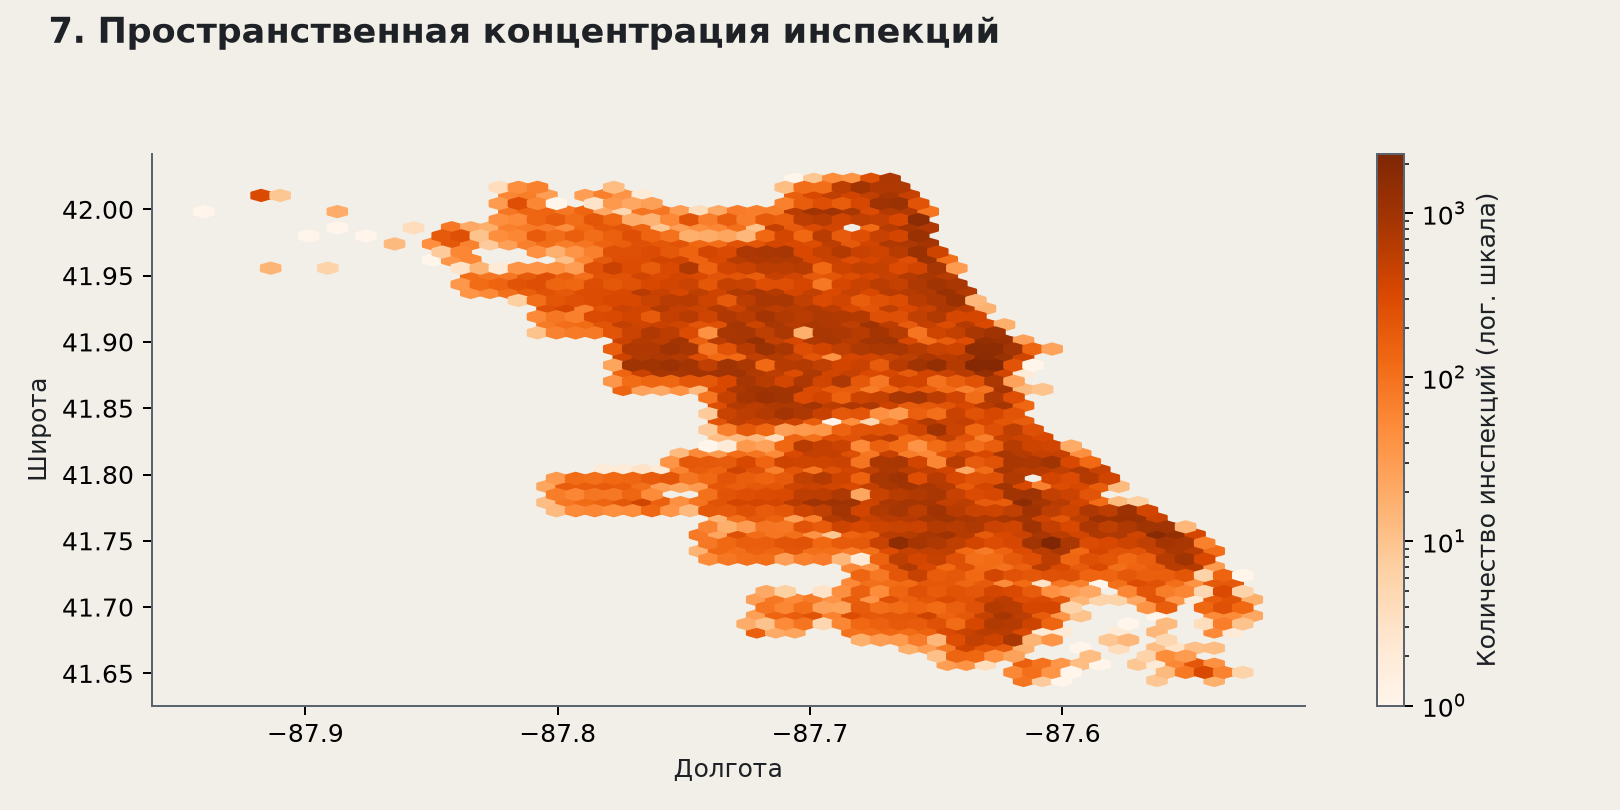

**Вывод.** У 502 инспекций нет пригодных координат. Карта показывает интенсивность наблюдения в архиве, без нормировки на число зданий. География может помочь ранжированию, но не позволяет объявить район более опасным.

In [11]:
display(Image(filename=str(FIG / (insights[6]['id'] + '.png'))))
display(Markdown('**Вывод.** ' + insights[6]['conclusion']))

## 5. Baseline

DummyClassifier(strategy='prior') и логистическая регрессия. Train: 2006–2023, validation: 2024, test: 2025. 2026 исключён из оценки. Импутация, OneHotEncoder и StandardScaler обучаются только на train. Текущие нарушения, результат, waived и история меток не используются.

Порог минимизирует 5×FN+FP на validation; модель и порог затем фиксируются. AP — average precision, а не трапецеидальная PR-AUC. Повторные объекты разрешены: тест соответствует будущим проверкам известного парка.

,n,failed_share,date_from,date_to
train,328294,0.730281,2006-01-01,2023-12-31
validation,10594,0.769492,2024-01-01,2024-12-31
test,10910,0.793859,2025-01-01,2025-12-31


,model,split,n,prevalence,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier,cost_per_inspection,tn,fp,fn,tp,fit_seconds
0,Dummy prior,validation,10594,0.769492,0.000,0.769492,0.500000,0.769492,1.000000,0.869732,0.500000,0.769492,0.178911,0.230508,0,2442,0,8152,0.011839
1,Dummy prior,test,10910,0.793859,0.000,0.793859,0.500000,0.793859,1.000000,0.885085,0.500000,0.793859,0.167689,0.206141,0,2249,0,8661,0.011839
2,Logistic regression,validation,10594,0.769492,0.235,0.806589,0.580610,0.799196,0.999877,0.888344,0.828658,0.925317,0.119519,0.193789,394,2048,1,8151,1.353977
3,Logistic regression,test,10910,0.793859,0.235,0.817782,0.561318,0.814497,0.997691,0.896834,0.810353,0.928456,0.119476,0.189551,281,1968,20,8641,1.353977


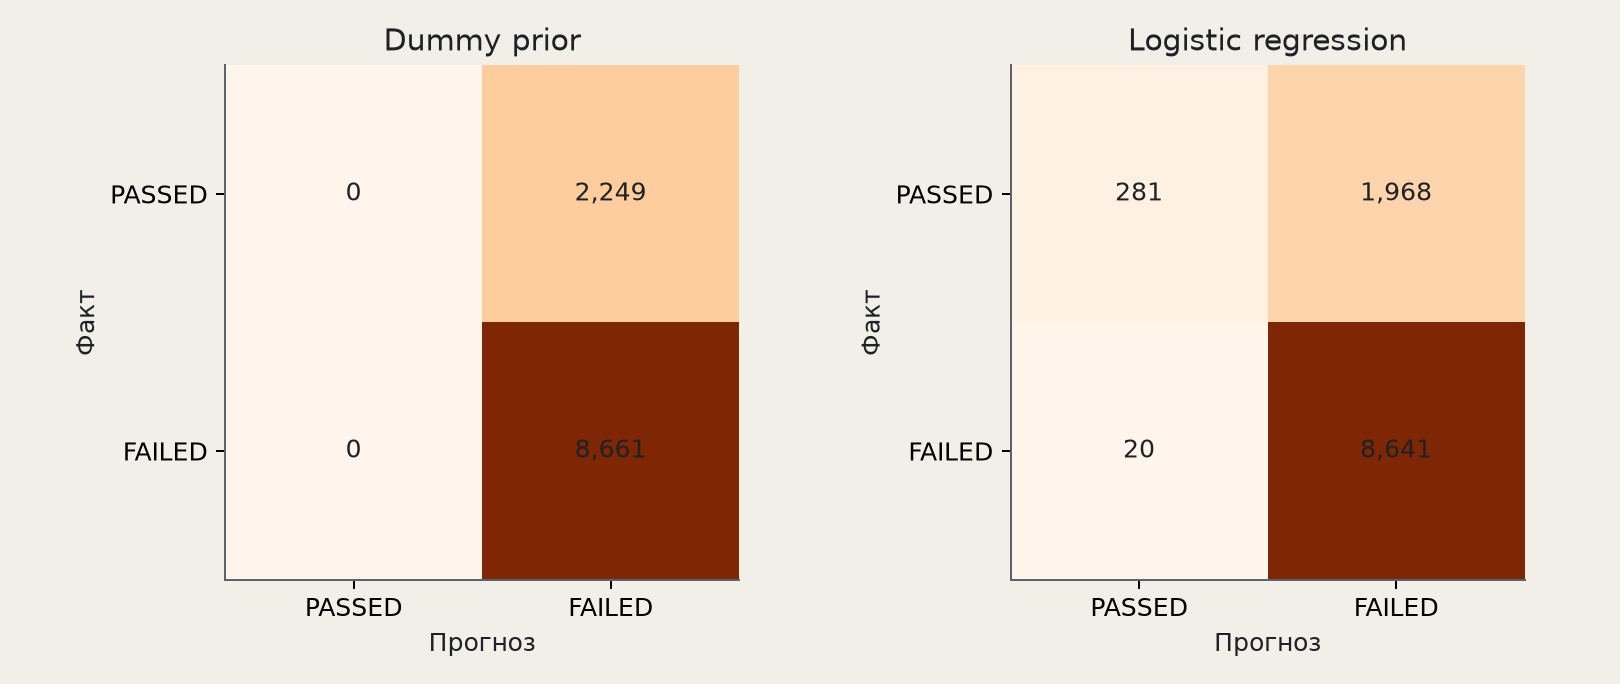

Критерий успеха выполнен: True


In [12]:
baseline = pipeline.model(model_data)
metrics = pd.DataFrame(baseline['metrics'])
display(pd.DataFrame(baseline['splits']).T)
display(metrics)
display(Image(filename=str(FIG / 'baseline_confusion.png')))
print('Критерий успеха выполнен:', baseline['success_criterion_met'])

In [13]:
test = metrics.query("split == 'test' and model == 'Logistic regression'").iloc[0]
print(f"Приоритет получает {(test.tp + test.fp)/test.n:.1%} тестовых инспекций")
print(f"Ложные тревоги среди PASSED: {test.fp/(test.fp+test.tn):.1%}")
print('Условная цена 5:1 даёт широкий охват; экономия внимания и переносимость пока не доказаны.')

Приоритет получает 97.2% тестовых инспекций
Ложные тревоги среди PASSED: 87.5%
Условная цена 5:1 даёт широкий охват; экономия внимания и переносимость пока не доказаны.


## 6. План и риски

- Недели 8–9: уточнить статусы, реальную дату инспекции и доступность полей до осмотра.
- Недели 10–11: получить полный журнал, включая проверки без нарушений, и локальные данные СМР.
- Недели 12–13: rolling backtest, отдельный тест новых объектов, модель без службы/категории, проверка калибровки.
- Недели 14–15: подтвердить стоимость ошибок и лимит внимания, сравнить простое дерево, оценить precision@K.

Основные риски: смещение отбора журнала; отличие Чикаго от локального СМР; изменения исторических статусов; неоднозначность даты и отбора; дрейф служб; условная цена ошибок. Разработка и внедрение приложения не входят в эту сдачу.

Источники: [данные](https://data.cityofchicago.org/Buildings/Building-Violations/22u3-xenr), [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html), [утечка и preprocessing](https://scikit-learn.org/stable/common_pitfalls.html), [AP](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

Отчёт и презентация строятся функцией `src.artifacts.main()` или командой `python -m src.artifacts`. PDF экспортируется через LibreOffice. Оригинальные материалы сохранены в `archive/`.